In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, balanced_accuracy_score

In [3]:
df = pd.read_csv('train.csv')
print(df.shape)
print(df.dtypes)
df.head()

(577347, 12)
id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [4]:
print(df.isnull().sum())

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64


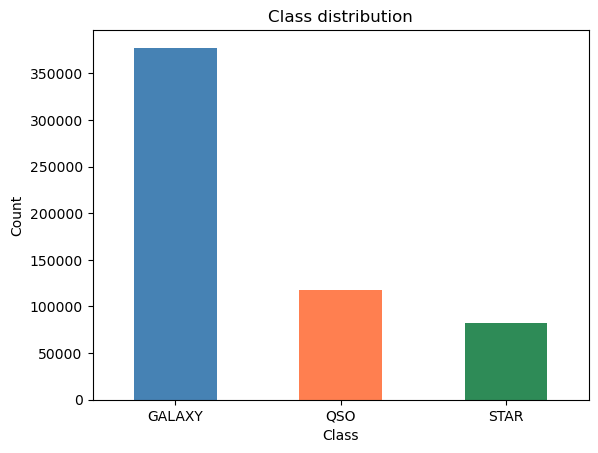

In [5]:
df['class'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'seagreen'])
plt.title('Class distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [6]:
print(df.groupby('class')['spectral_type'].value_counts())

class   spectral_type
GALAXY  M                288023
        G/K               61627
        A/F               24240
        O/B                3590
QSO     A/F               61514
        O/B               30819
        G/K               20921
        M                  3889
STAR    A/F               36368
        G/K               25998
        M                 11411
        O/B                8947
Name: count, dtype: int64


In [7]:
print(df.groupby('class')['galaxy_population'].value_counts())

class   galaxy_population
GALAXY  Red_Sequence         288518
        Blue_Cloud            88962
QSO     Blue_Cloud           108274
        Red_Sequence           8869
STAR    Blue_Cloud            60546
        Red_Sequence          22178
Name: count, dtype: int64


In [8]:
neumeric_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
df.groupby('class')[neumeric_cols].mean()

,alpha,delta,u,g,r,i,z,redshift
class,,,,,,,,
GALAXY,178.557241,21.033443,22.989160,21.270147,19.860511,19.068222,18.629897,0.509026
QSO,189.665998,25.811829,21.724756,21.160314,20.918809,20.767309,20.602139,1.875641
STAR,184.178832,19.858725,20.960388,19.591033,19.075853,18.830555,18.707180,0.068115


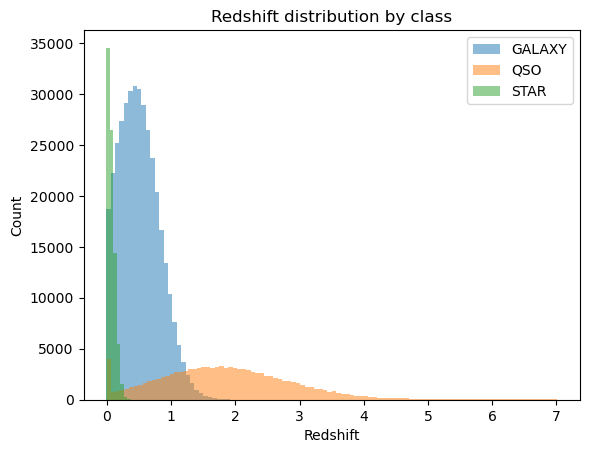

In [9]:
for cls in df['class'].unique():
  subset = df[df['class'] == cls]['redshift']
  plt.hist(subset, bins=100, alpha=0.5, label=cls)

plt.title('Redshift distribution by class')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.legend()
plt.show()

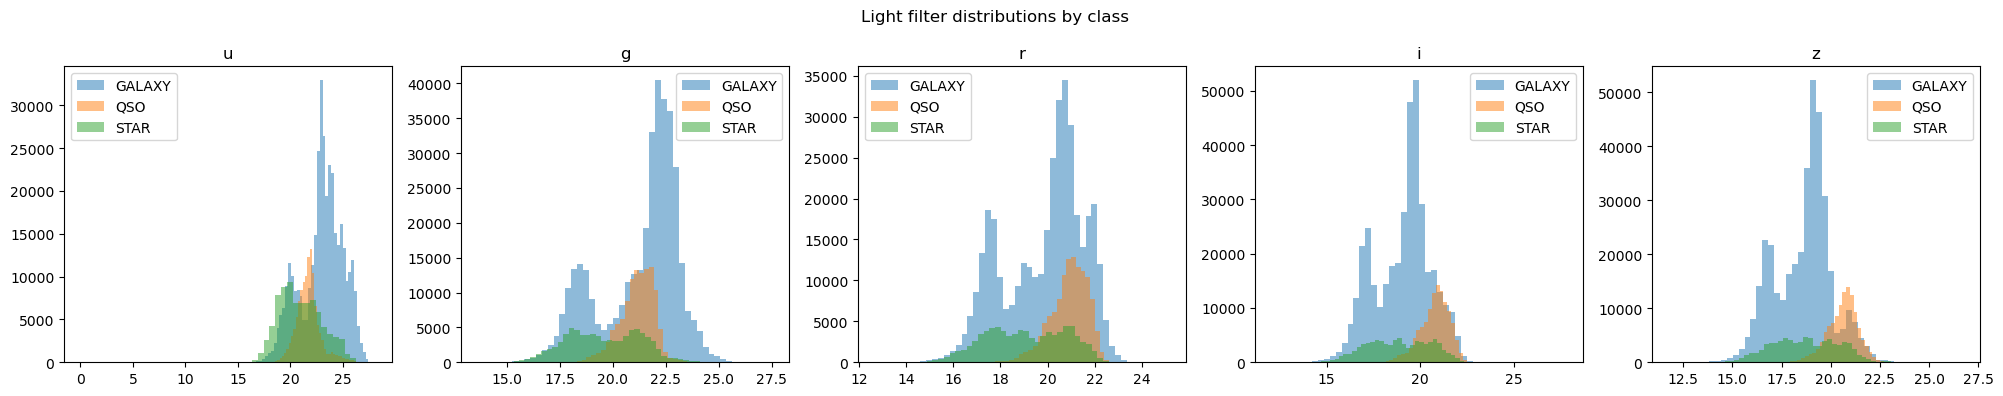

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, ['u', 'g', 'r', 'i', 'z']):
    for cls in df['class'].unique():
        ax.hist(df[df['class'] == cls][col], bins=50, alpha=0.5, label=cls)
    ax.set_title(col)
    ax.legend()
plt.suptitle('Light filter distributions by class')
plt.tight_layout()
plt.show()


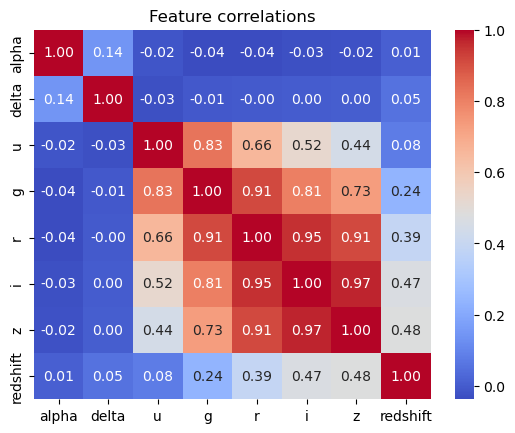

In [11]:
numeric_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlations')
plt.show()

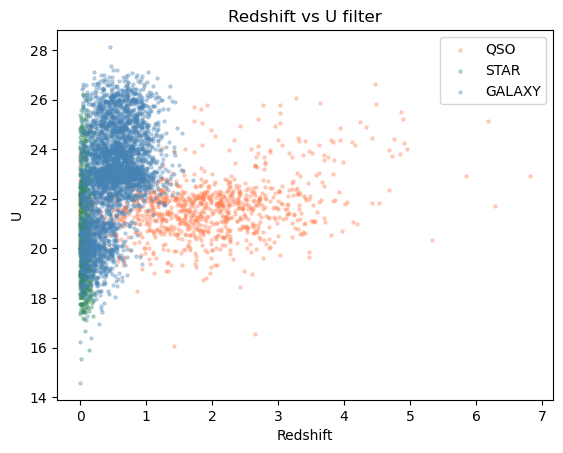

In [12]:
sample = df.sample(5000, random_state=42)   
colors = {'GALAXY': 'steelblue', 'QSO': 'coral', 'STAR': 'seagreen'}
for cls in sample['class'].unique():
    subset = sample[sample['class'] == cls]
    plt.scatter(subset['redshift'], subset['u'], alpha=0.3, 
                label=cls, color=colors[cls], s=5)
plt.title('Redshift vs U filter')
plt.xlabel('Redshift')
plt.ylabel('U')
plt.legend()
plt.show()

In [13]:
#One-hot encoding
df = pd.get_dummies(df, columns=['spectral_type', 'galaxy_population'])

#Features X
X = df.drop(columns=['id', 'class']).to_numpy()

# Target encoding(y)
le = LabelEncoder()
y = le.fit_transform(df['class'].to_numpy())

print("X shape:", X.shape)
print("Classes:", le.classes_)

X shape: (577347, 14)
Classes: ['GALAXY' 'QSO' 'STAR']


In [14]:
X_train, X_val, y_train, y_val, = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Train:", X_train.shape)
print("Val:", X_val.shape)


Train: (461877, 14)
Val: (115470, 14)


In [15]:
class StellarDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y)
  
  def __len__(self):
    return len(self.X)
  
  def __getitem__(self, i):
    return self.X[i], self.y[i]
  
train_loader = DataLoader(StellarDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader = DataLoader(StellarDataset(X_val, y_val), batch_size=256, shuffle=True)


In [16]:
class Classifer(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 32)
    self.fc4 = nn.Linear(32, 16)
    self.fc5 = nn.Linear(16, 3)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.3)

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.relu(self.fc2(x))
    x = self.dropout(x)
    x = self.relu(self.fc3(x))
    x = self.dropout(x)
    x = self.relu(self.fc4(x))
    x = self.fc5(x)
    return x

In [17]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using", device)

Using cuda


In [18]:
model = Classifer(input_dim=X_train.shape[1]).to(device)
print(model)

Classifer(
  (fc1): Linear(in_features=14, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=16, bias=True)
  (fc5): Linear(in_features=16, out_features=3, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [19]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(loader, epoch):
    model.train()
    total_loss, correct = 0, 0
    bar = tqdm(loader, desc=f"Epoch {epoch+1} train", leave=False)
    for X_batch, y_batch in bar:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == y_batch).sum().item()
        bar.set_postfix(loss=f"{loss.item():.4f}")   
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(loader, epoch):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    bar = tqdm(loader, desc=f"Epoch {epoch+1} val  ", leave=False)
    with torch.no_grad():
        for X_batch, y_batch in bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            total_loss += criterion(logits, y_batch).item()
            all_preds.append(logits.argmax(1).cpu())
            all_labels.append(y_batch.cpu())
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc     = (all_preds == all_labels).mean()
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc, bal_acc, all_preds, all_labels

In [20]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'bal_acc': []}

for epoch in range(30):
    train_loss, train_acc                      = train_epoch(train_loader, epoch)
    val_loss, val_acc, bal_acc, preds, labels  = eval_epoch(val_loader, epoch)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['bal_acc'].append(bal_acc)

    print(f"Epoch {epoch+1:3d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} | "
          f"bal acc {bal_acc:.3f}")

Epoch   1 | train loss 0.2307 acc 0.913 | val loss 0.1457 acc 0.946 | bal acc 0.917


Epoch   2 | train loss 0.1619 acc 0.941 | val loss 0.1369 acc 0.950 | bal acc 0.928


Epoch   3 | train loss 0.1531 acc 0.945 | val loss 0.1319 acc 0.952 | bal acc 0.931


Epoch   4 | train loss 0.1490 acc 0.946 | val loss 0.1311 acc 0.952 | bal acc 0.928


Epoch   5 | train loss 0.1461 acc 0.947 | val loss 0.1320 acc 0.952 | bal acc 0.931


...

Epoch  26 | train loss 0.1349 acc 0.951 | val loss 0.1251 acc 0.955 | bal acc 0.938


Epoch  27 | train loss 0.1341 acc 0.951 | val loss 0.1235 acc 0.955 | bal acc 0.937


Epoch  28 | train loss 0.1340 acc 0.951 | val loss 0.1240 acc 0.956 | bal acc 0.940


Epoch  29 | train loss 0.1336 acc 0.951 | val loss 0.1221 acc 0.956 | bal acc 0.936


Epoch  30 | train loss 0.1337 acc 0.951 | val loss 0.1239 acc 0.956 | bal acc 0.936


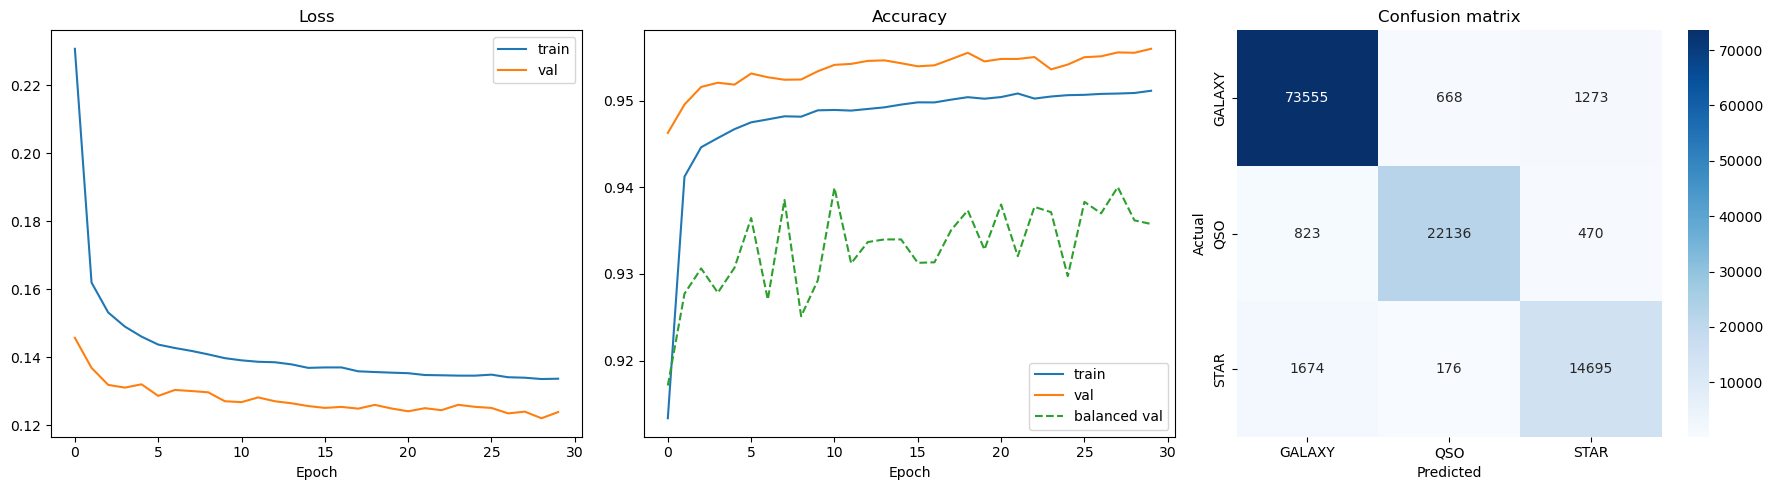

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'],   label='val')
axes[1].plot(history['bal_acc'],   label='balanced val', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

class_names = ['GALAXY', 'QSO', 'STAR']
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[2])
axes[2].set_title('Confusion matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(
    "images/results.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()